In [1]:
# --- Standard Libraries ---
import os

# --- Data Manipulation ---
import pandas as pd
import numpy as np

# --- Signal Processing & Statistics ---
from scipy.fft import fft, fftfreq
import scipy.stats as stats

# --- Visualization ---
import matplotlib.pyplot as plt

# Optional: Make matplotlib plots look a bit more modern automatically
plt.style.use('seaborn-v0_8-darkgrid')

### 1. Baseline Vibration Signal: Healthy State (Day 1)

This plot visualizes the time-domain vibration signal for **Bearing 1 (Column 0)** at the very beginning of the run-to-failure experiment (`2004.02.12`). [2nd_test] 

* **Condition:** Brand new, healthy bearing.
* **Purpose:** This establishes the baseline amplitude and normal operational vibration pattern. The machine is running smoothly under a 6000 lbs load at 2000 RPM, serving as our "ground truth" for a healthy state before any degradation begins.

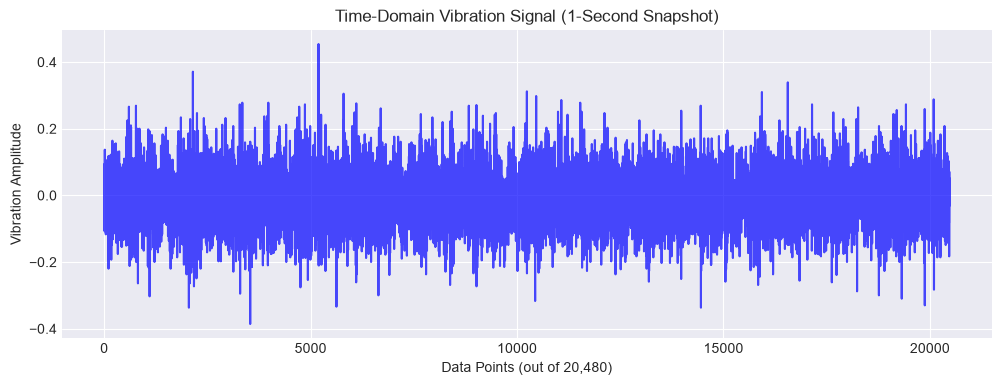

In [2]:
# Point this to the very first file in your 2nd_test folder (Healthy state)
# Update the filename to match an actual file in your directory
file_path = './bearing-dataset/2nd_test/2nd_test/2004.02.12.10.32.39' 

# The NASA dataset is tab-separated and has no header row
df = pd.read_csv(file_path, sep='\t', header=None)

# Let's look at Sensor 1 (Column 0)
plt.figure(figsize=(12, 4))
plt.plot(df[0], color='blue', alpha=0.7)
plt.title('Time-Domain Vibration Signal (1-Second Snapshot)')
plt.xlabel('Data Points (out of 20,480)')
plt.ylabel('Vibration Amplitude')
plt.grid(True)
plt.show()

### 2. Degraded Vibration Signal: Failed State (End of Test)

This plot visualizes the time-domain vibration signal for the exact same bearing (**Bearing 1 / Column 0**) at the very end of the experiment (`2004.02.19`). [2nd_test]

* **Condition:** Complete failure (Outer Race Defect).
* **Observation:** Notice the massive, chaotic spikes in amplitude compared to the baseline healthy state. These violent peaks represent the physical impacts of the rolling elements striking the crack in the bearing's outer metal ring as it rotates.

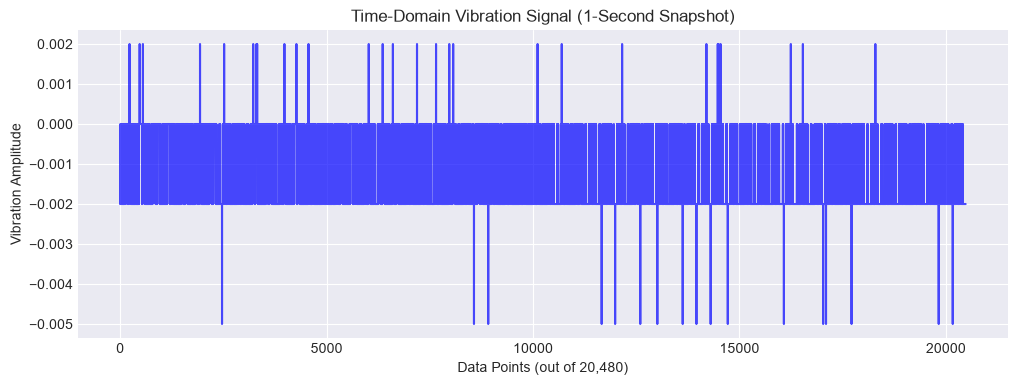

In [3]:
df1 = pd.read_csv('./bearing-dataset/2nd_test/2nd_test/2004.02.19.06.22.39', sep='\t', header=None)

plt.figure(figsize=(12, 4))
plt.plot(df1[0], color='blue', alpha=0.7)
plt.title('Time-Domain Vibration Signal (1-Second Snapshot)')
plt.xlabel('Data Points (out of 20,480)')
plt.ylabel('Vibration Amplitude')
plt.grid(True)
plt.show()

### 3. Full System Comparison: Healthy vs. Failed State

To ensure our AI agent correctly isolates faults, we must verify that the failure is localized. This grid compares the time-domain vibration signals of all four bearings on Day 1 versus the final day of testing.

* **Left Column (Blue):** Day 1 (`2004.02.12`) - All bearings are brand new and operating normally. Notice the small scale on the y-axis.
* **Right Column (Red):** End of Test (`2004.02.19`) - The machine has been running continuously. 
* **Key Observation:** By comparing the y-axis scales, we can determine if the chaotic vibration is isolated to Bearing 1 or if it propagated through the entire shaft to Bearings 2, 3, and 4.

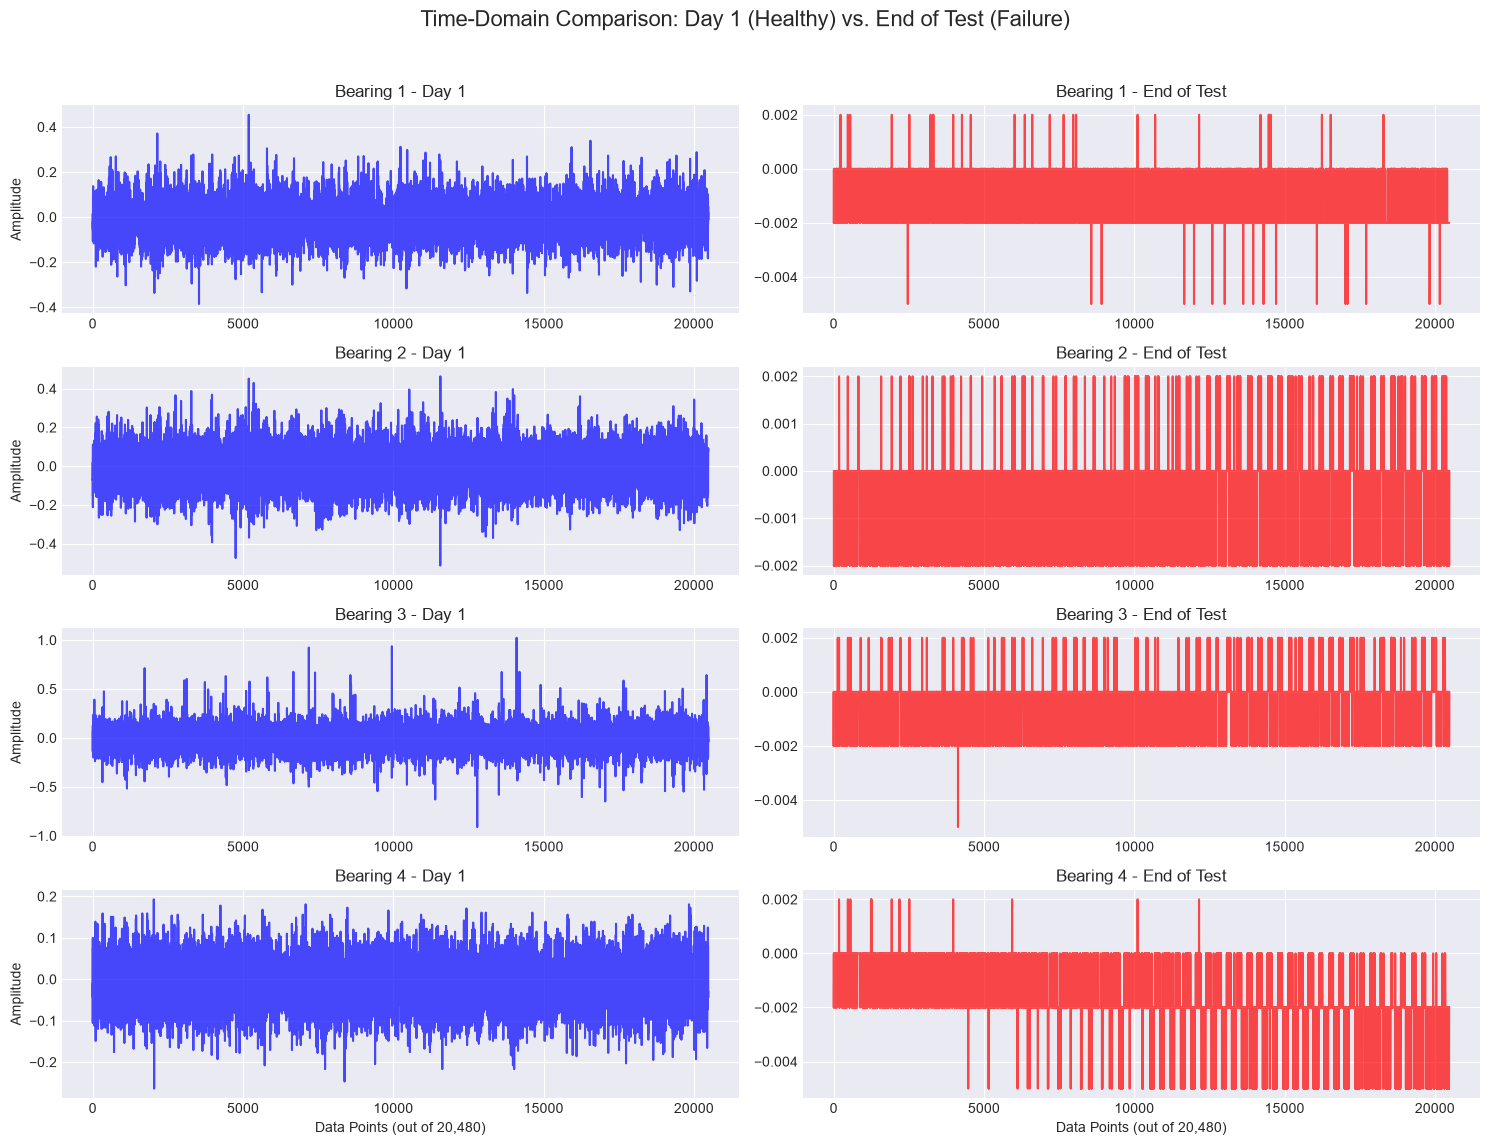

In [4]:
# File paths based on your directory structure
file_first = './bearing-dataset/2nd_test/2nd_test/2004.02.12.10.32.39'
file_last = './bearing-dataset/2nd_test/2nd_test/2004.02.19.06.22.39'

# Load the data
df_first = pd.read_csv(file_first, sep='\t', header=None)
df_last = pd.read_csv(file_last, sep='\t', header=None)

# Create a 4x2 grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 12))
fig.suptitle('Time-Domain Comparison: Day 1 (Healthy) vs. End of Test (Failure)', fontsize=16)

bearing_names = ['Bearing 1', 'Bearing 2', 'Bearing 3', 'Bearing 4']

for i in range(4):
    # Left Column: Day 1 (Healthy)
    axes[i, 0].plot(df_first[i], color='blue', alpha=0.7)
    axes[i, 0].set_title(f'{bearing_names[i]} - Day 1')
    axes[i, 0].set_ylabel('Amplitude')
    axes[i, 0].grid(True)
    
    # Right Column: End of Test (Faulty)
    axes[i, 1].plot(df_last[i], color='red', alpha=0.7)
    axes[i, 1].set_title(f'{bearing_names[i]} - End of Test')
    axes[i, 1].grid(True)

# Add X-axis labels only to the bottom row to keep it clean
axes[3, 0].set_xlabel('Data Points (out of 20,480)')
axes[3, 1].set_xlabel('Data Points (out of 20,480)')

# Adjust layout so titles and labels don't overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

### 4. Frequency-Domain Analysis: Fast Fourier Transform (FFT)

This section converts the raw, time-based vibration wave into a frequency spectrum using a Fast Fourier Transform (FFT). 

* **The Goal:** While the time-domain plot just shows us that the machine is vibrating violently, the frequency domain isolates the exact mathematical frequencies where that vibration energy is concentrated.
* **Why it Matters for the Agent:** Physical defects (like a crack on the outer race) cause repeated impacts at highly specific, calculable frequencies based on the bearing's physical geometry. This FFT plot will reveal those hidden "fault signatures" as distinct spikes, providing the deterministic, explainable proof your AI agent needs to diagnose the root cause.

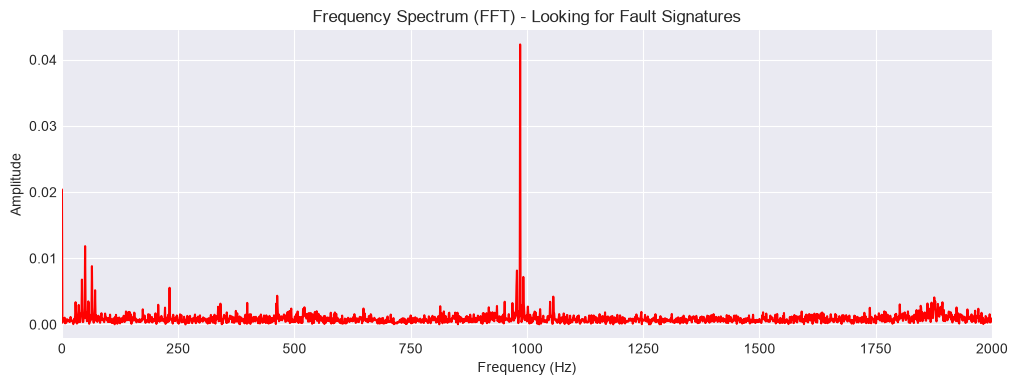

In [5]:
# Assuming 'df[0]' is your 1-second vibration signal from the first cell
signal = df[0].values
N = len(signal)      # Number of data points (20,480)
T = 1.0 / 20000.0    # Sample spacing (1 / 20 kHz)

# Perform the FFT
yf = fft(signal)
xf = fftfreq(N, T)[:N//2] # Get only the positive frequencies

# Plot the frequency spectrum
plt.figure(figsize=(12, 4))
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]), color='red')
plt.title('Frequency Spectrum (FFT) - Looking for Fault Signatures')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 2000) # Zoom in on the lower frequencies where faults appear
plt.grid(True)
plt.show()

In [6]:
def extract_features(signal):
    """Calculates key statistical features for a 1D array of vibration data."""
    rms = np.sqrt(np.mean(signal**2))
    kurt = stats.kurtosis(signal, fisher=False)
    p2p = np.max(signal) - np.min(signal)
    crest_factor = np.max(np.abs(signal)) / rms if rms > 0 else 0
    return rms, kurt, p2p, crest_factor

# Define the path to your dataset folder
folder_path = './bearing-dataset/2nd_test/2nd_test/'

# Get all files and sort them chronologically based on filename
file_names = sorted(os.listdir(folder_path))

# List to hold the extracted data
dataset_rows = []

print(f"Processing {len(file_names)} files. This might take a minute...")

for file in file_names:
    file_path = os.path.join(folder_path, file)
    
    # Read the file
    df = pd.read_csv(file_path, sep='\t', header=None)
    
    # Dictionary to store the row data (starting with the timestamp/filename)
    row_data = {'Timestamp': file}
    
    # Loop through all 4 bearings (Columns 0 to 3)
    for i in range(4):
        rms, kurt, p2p, crest = extract_features(df[i].values)
        
        # Append features with bearing labels (e.g., B1_RMS)
        row_data[f'B{i+1}_RMS'] = rms
        row_data[f'B{i+1}_Kurtosis'] = kurt
        row_data[f'B{i+1}_Peak2Peak'] = p2p
        row_data[f'B{i+1}_CrestFactor'] = crest
        
    dataset_rows.append(row_data)

# Convert the list of dictionaries into a structured DataFrame
features_df = pd.DataFrame(dataset_rows)

# Save the compiled dataset to a CSV file in your main folder
output_filename = 'bearing_features_dataset.csv'
features_df.to_csv(f'./{output_filename}', index=False)

print(f"Extraction complete! Dataset saved as '{output_filename}'.")
features_df.head()

Processing 984 files. This might take a minute...
Extraction complete! Dataset saved as 'bearing_features_dataset.csv'.


,Timestamp,B1_RMS,B1_Kurtosis,B1_Peak2Peak,B1_CrestFactor,B2_RMS,B2_Kurtosis,B2_Peak2Peak,B2_CrestFactor,B3_RMS,B3_Kurtosis,B3_Peak2Peak,B3_CrestFactor,B4_RMS,B4_Kurtosis,B4_Peak2Peak,B4_CrestFactor
0,2004.02.12.10.32.39,0.074179,3.628763,0.840,6.120331,0.090944,3.506801,0.977,5.640841,0.109404,6.213075,1.934,9.350652,0.054103,3.065959,0.457,4.879539
1,2004.02.12.10.42.39,0.075382,3.648291,0.757,5.147086,0.093419,3.253014,0.938,5.148852,0.109817,4.395250,1.433,6.847735,0.056101,3.107539,0.478,4.438435
2,2004.02.12.10.52.39,0.076230,3.513475,0.903,6.598472,0.093718,3.310789,0.994,5.367171,0.109861,5.639948,1.719,8.492546,0.056145,3.257236,0.688,6.305078
3,2004.02.12.11.02.39,0.078724,4.157953,1.184,7.723217,0.092947,3.235341,1.043,6.121762,0.110667,5.682779,1.951,9.180734,0.056807,3.806190,1.038,9.241749
4,2004.02.12.11.12.39,0.078474,3.603177,0.782,4.982524,0.095348,3.226309,0.938,5.097120,0.107506,4.578395,1.516,7.171719,0.056841,3.138954,0.456,4.292680


In [7]:
# 1. Load the features dataset you just created
df = pd.read_csv('./bearing_features_dataset.csv')

# 2. Convert the 'Timestamp' string (filename) into a true datetime object
# Format matches the NASA filenames: 2004.02.12.10.32.39
df['Datetime'] = pd.to_datetime(df['Timestamp'], format='%Y.%m.%d.%H.%M.%S')

# 3. Identify the exact time of failure (the very last file in the test)
time_of_failure = df['Datetime'].max()

# 4. Calculate Remaining Useful Life (RUL) in hours for every single row
df['RUL_Hours'] = (time_of_failure - df['Datetime']).dt.total_seconds() / 3600.0

# 5. Drop the intermediate Datetime column and save the updated dataset
df = df.drop(columns=['Datetime'])
df.to_csv('./bearing_features_dataset_with_RUL.csv', index=False)

print("RUL successfully calculated!")
# Display the first and last few rows to verify the RUL countdown
display(df[['Timestamp', 'B1_RMS', 'RUL_Hours']].iloc[[0, 1, -2, -1]])

RUL successfully calculated!


,Timestamp,B1_RMS,RUL_Hours
0,2004.02.12.10.32.39,0.074179,163.833333
1,2004.02.12.10.42.39,0.075382,163.666667
982,2004.02.19.06.12.39,0.002103,0.166667
983,2004.02.19.06.22.39,0.001533,0.000000
